# Data Loading and Data Description

In [1]:
import pandas as pd

file_path = '/content/embedded_system_network_security_dataset.csv'
df = pd.read_csv(file_path)
print("Data Shape (rows, columns):", df.shape)

print("\nNull values per column:")
print(df.isnull().sum())
print("\nPercentage of null values per column:")
print((df.isnull().mean() * 100).round(2))
print("\nDataframe info:")
df.info()
print("\nDescriptive statistics of numeric columns:")
print(df.describe())
print("\nFirst 5 rows:")
print(df.head())


Data Shape (rows, columns): (1000, 18)

Null values per column:
packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
dtype: int64

Percentage of null values per column:
packet_size              0.0
inter_arrival_time       0.0
src_port                 0.0
dst_port                 0.0
packet_count_5s          0.0
mean_packet_size         0.0
spectral_entropy         0.0
frequency_band_energy    0.0
label                    0.0
protocol_type_TCP        0.0
protocol_type_UDP        0.0
src_ip_192.168.1.2       0.0
src_ip_192.168.1.3       0.0
dst_ip_192.168.1.5   

In [2]:
!pip install transformers
!pip install torch torchvision
!pip install pytorch_wavelets

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import ViTModel
import torchvision.transforms as transforms
import random
from pytorch_wavelets import DWTForward
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.1 MB/s eta 0:00:00


In [295]:
df = pd.read_csv('/content/embedded_system_network_security_dataset.csv')
labels = df['label'].values

feature_cols = df.columns.drop('label')
df[feature_cols] = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()

# Split (first 70% train, last 30% test)
num_samples = len(df)
split_idx = int(0.7 * num_samples)
train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df = df.iloc[split_idx:].reset_index(drop=True)

train_data = train_df.drop('label', axis=1).values
test_data = test_df.drop('label', axis=1).values

train_labels = labels[:split_idx]
test_labels = labels[split_idx:]


In [296]:
# For TRAIN set
num_anomalies_train = np.sum(train_labels == 1)
num_normals_train = np.sum(train_labels == 0)
print(f"Training set: {num_anomalies_train} anomalies, {num_normals_train} normal")

# For TEST set
num_anomalies_test = np.sum(test_labels == 1)
num_normals_test = np.sum(test_labels == 0)
print(f"Test set: {num_anomalies_test} anomalies, {num_normals_test} normal")

# To see class balance as percentages
print(f"Training anomaly ratio: {num_anomalies_train / len(train_labels):.2%}")
print(f"Test anomaly ratio: {num_anomalies_test / len(test_labels):.2%}")


Training set: 69 anomalies, 631 normal
Test set: 31 anomalies, 269 normal
Training anomaly ratio: 9.86%
Test anomaly ratio: 10.33%


In [716]:
window_size, step = 24, 8

def create_windows(data, labels, window_size, step):
    X, y, indices = [], [], []
    for i in range(0, len(data) - window_size + 1, step):
        X.append(data[i:i+window_size])
        y.append(labels[i:i+window_size].mean())
        indices.append(list(range(i, i+window_size)))
    return np.stack(X), np.array(y), indices

X_train_win, y_train_win, train_indices = create_windows(train_data, train_labels, window_size, step)
X_test_win, y_test_win, test_indices = create_windows(test_data, test_labels, window_size, step)

In [717]:
def crop_windows(X, patch=16):
    feat, win = X.shape[1], X.shape[2]
    crop_feat = feat - (feat % patch) or feat
    crop_win = win - (win % patch) or win
    return X[:, :crop_feat, :crop_win]
X_train_win = crop_windows(X_train_win)
X_test_win  = crop_windows(X_test_win)

resize_target = (96, 96)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(resize_target[::-1]),
    transforms.ToTensor()
])

In [718]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X.astype(np.float32), y.astype(np.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        from PIL import Image
        img = self.X[idx]
        img_norm = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-8)
        img_norm = np.nan_to_num(img_norm, nan=0)
        img_uint8 = (img_norm * 255).astype(np.uint8)
        pil_img = Image.fromarray(img_uint8)
        pil_img = pil_img.resize(resize_target[::-1], Image.BILINEAR)
        img_tensor = transforms.ToTensor()(pil_img)
        return img_tensor, torch.tensor(self.y[idx])

train_ds, test_ds = WindowDataset(X_train_win, y_train_win), WindowDataset(X_test_win, y_test_win)
train_dl, test_dl = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2), DataLoader(test_ds, batch_size=8, num_workers=2)


In [719]:
class ViTWithWaveletAdapter(nn.Module):
    def __init__(self, vit_model):
        super().__init__()
        self.dwt = DWTForward(J=1, mode='zero', wave='haar')
        self.vit = vit_model
        self.adapter = nn.Sequential(
            nn.Linear(vit_model.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        Yl, Yh = self.dwt(x)
        detail_bands = Yh[0]
        processed_bands = []
        target_size, target_batch = Yl.shape[2:], Yl.shape[0]
        for band in detail_bands:
            while band.dim() > 4: band = band.squeeze(dim=-1)
            if band.shape[0] == 1 and target_batch > 1:
                band = band.repeat(target_batch, *[1]*(band.dim()-1))
            if band.shape[2:] != target_size:
                band = nn.functional.interpolate(band, size=target_size, mode='bilinear', align_corners=False)
            processed_bands.append(band)
        Yh_cat = torch.cat(processed_bands, dim=1)
        x_wave = torch.cat([Yl, Yh_cat], dim=1)
        x_wave_upsampled = nn.functional.interpolate(x_wave, size=(224, 224), mode='bilinear', align_corners=False)
        x_in = x_wave_upsampled.mean(dim=1, keepdim=True).repeat(1, 3, 1, 1)
        outputs = self.vit(pixel_values=x_in)
        pooled = outputs.pooler_output
        return self.adapter(pooled)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = 'google/vit-base-patch16-224-in21k'
vit_model = ViTModel.from_pretrained(model_name)
for p in vit_model.parameters(): p.requires_grad = False
model = ViTWithWaveletAdapter(vit_model).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.adapter.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler()


Epoch 1/50, Loss: 0.037065
Epoch 2/50, Loss: 0.008530
Epoch 3/50, Loss: 0.004913
Epoch 4/50, Loss: 0.003860
Epoch 5/50, Loss: 0.004239
Epoch 6/50, Loss: 0.004379
Epoch 7/50, Loss: 0.004113
Epoch 8/50, Loss: 0.003902
Epoch 9/50, Loss: 0.002609
Epoch 10/50, Loss: 0.002628
Epoch 11/50, Loss: 0.003292
Epoch 12/50, Loss: 0.002925
Epoch 13/50, Loss: 0.002676
Epoch 14/50, Loss: 0.002832
Epoch 15/50, Loss: 0.004585
Epoch 16/50, Loss: 0.003955
Epoch 17/50, Loss: 0.003443
Epoch 18/50, Loss: 0.002634
Epoch 19/50, Loss: 0.003195
Epoch 20/50, Loss: 0.003770
Epoch 21/50, Loss: 0.003351
Epoch 22/50, Loss: 0.002473
Epoch 23/50, Loss: 0.002661
Epoch 24/50, Loss: 0.003197
Epoch 25/50, Loss: 0.003859
Epoch 26/50, Loss: 0.002259
Epoch 27/50, Loss: 0.002359
Epoch 28/50, Loss: 0.002388
Epoch 29/50, Loss: 0.002710
Epoch 30/50, Loss: 0.003171
Epoch 31/50, Loss: 0.002297
Epoch 32/50, Loss: 0.003175
Epoch 33/50, Loss: 0.002500
Epoch 34/50, Loss: 0.002900
Epoch 35/50, Loss: 0.002523
Epoch 36/50, Loss: 0.003441
E

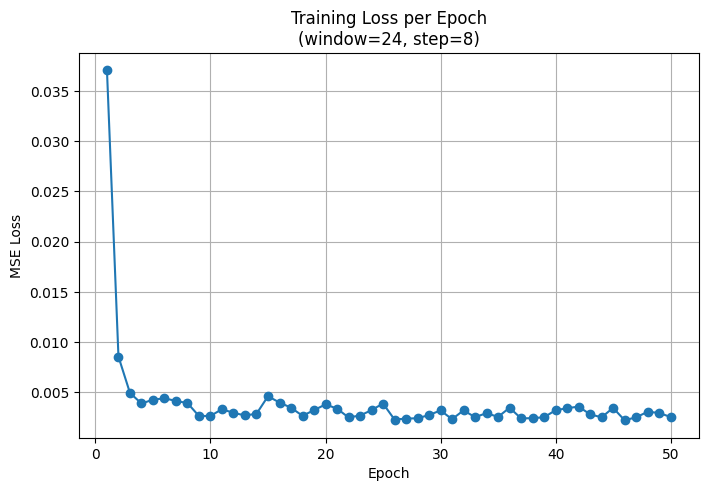

In [720]:
epochs = 50
epoch_losses, train_scores = [], []
model.train()
for epoch in range(epochs):
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            preds = model(xb)
            loss = criterion(preds, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * xb.size(0)
        # --- FIX IS HERE ---
        score_array = preds.squeeze().detach().cpu().numpy()
        if np.isscalar(score_array) or score_array.ndim == 0:
            train_scores.append(float(score_array))
        else:
            train_scores.extend(score_array)
    avg_loss = total_loss / len(train_dl.dataset)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), epoch_losses, marker='o')
plt.title(f"Training Loss per Epoch\n(window={window_size}, step={step})")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

filename = f"training_win{window_size}_step{step}.png"
plt.savefig(filename, bbox_inches='tight')
plt.show()



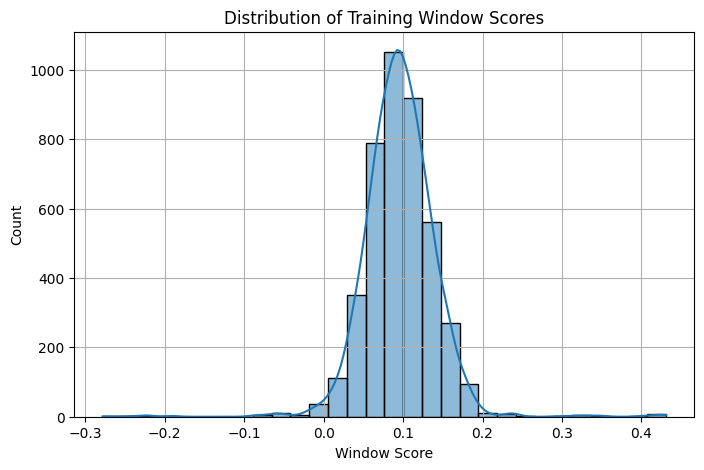

In [721]:
import matplotlib.pyplot as plt
import seaborn as sns
#training Score Distribution
plt.figure(figsize=(8, 5))
sns.histplot(train_scores, bins=30, kde=True)
plt.title("Distribution of Training Window Scores")
plt.xlabel("Window Score")
plt.ylabel("Count")
plt.grid(True)
plt.show()


In [722]:
# Anomaly thresholds from train window scores
lower_th = np.mean(train_scores) - np.std(train_scores)
upper_th = np.mean(train_scores) + np.std(train_scores)
print(f"Lower threshold : {lower_th:.5f}, Upper threshold : {upper_th:.5f}")

Lower threshold : 0.05081, Upper threshold : 0.14087


In [723]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Test Phase
model.eval()
test_scores = []
for xb, _ in test_dl:
    xb = xb.to(device)
    with torch.no_grad():
        preds = model(xb)
    preds_np = preds.squeeze().cpu().numpy()
    if np.isscalar(preds_np) or getattr(preds_np, "ndim", 0) == 0:
        test_scores.append(float(preds_np))
    else:
        test_scores.extend(preds_np)

# Window Level Evaluation

Window-level Classification Report:
              precision    recall  f1-score   support

           0       0.09      1.00      0.16         3
           1       1.00      0.03      0.06        32

    accuracy                           0.11        35
   macro avg       0.54      0.52      0.11        35
weighted avg       0.92      0.11      0.07        35

Window-level Confusion Matrix:
[[ 3  0]
 [31  1]]


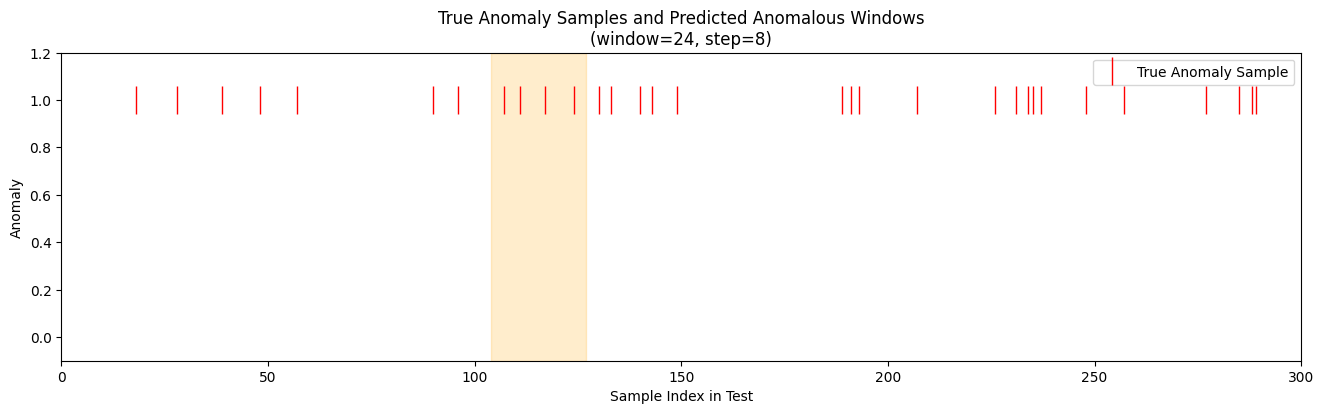

In [724]:
window_true = np.array([int(np.any(test_labels[idx_win] == 1)) for idx_win in test_indices])
window_pred = ((np.array(test_scores) < lower_th) | (np.array(test_scores) > upper_th)).astype(int)
from sklearn.metrics import classification_report, confusion_matrix

print("Window-level Classification Report:")
print(classification_report(window_true, window_pred, zero_division=0))
print("Window-level Confusion Matrix:")
print(confusion_matrix(window_true, window_pred))
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))

anomaly_samples = np.where(test_labels == 1)[0]
plt.plot(anomaly_samples, [1]*len(anomaly_samples), 'r|', markersize=20, label='True Anomaly Sample')


for i, idx_win in enumerate(test_indices):
    if window_pred[i] == 1:
        plt.axvspan(idx_win[0], idx_win[-1], color='orange', alpha=0.2)

plt.xlim(0, len(test_labels))
plt.ylim(-0.1, 1.2)
plt.xlabel('Sample Index in Test')
plt.ylabel('Anomaly')
plt.title(f"True Anomaly Samples and Predicted Anomalous Windows\n(window={window_size}, step={step})")
plt.legend(loc='upper right')
filename = f"windowlevel_win{window_size}_step{step}.png"
plt.savefig(filename, bbox_inches='tight')
plt.show()


In [725]:
import os
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Prepare result row
report = classification_report(window_true, window_pred, output_dict=True, zero_division=0)
precision_1 = report['1']['precision']
recall_1    = report['1']['recall']
f1_1        = report['1']['f1-score']
acc         = accuracy_score(window_true, window_pred)
try:
    roc_auc = roc_auc_score(window_true, np.array(test_scores))
except ValueError:
    roc_auc = float('nan')
# Prepare result row
result_row = {
    'window_size': window_size,
    'step_size': step,
    'precision_1': round(precision_1, 4),
    'recall_1': round(recall_1, 4),
    'f1_1': round(f1_1, 4),
    'accuracy': round(acc, 4),
    'roc_auc': round(roc_auc, 4)
}

results_path = 'results.csv'
if os.path.exists(results_path):
    df_results = pd.read_csv(results_path)
    match = ((df_results['window_size'] == window_size) & (df_results['step_size'] == step)).any()
    if not match:
        # Use pd.concat for a new row, then round before saving
        df_results = pd.concat([df_results, pd.DataFrame([result_row])], ignore_index=True)
        df_results = df_results.round(4)
        df_results.to_csv(results_path, index=False)
else:
    df_results = pd.DataFrame([result_row]).round(4)
    df_results.to_csv(results_path, index=False)

print("Results for this parameter combo:", result_row)


Results for this parameter combo: {'window_size': 24, 'step_size': 8, 'precision_1': 1.0, 'recall_1': 0.0312, 'f1_1': 0.0606, 'accuracy': 0.1143, 'roc_auc': np.float64(0.7604)}


# Sample-level aggregation using Mean

Sample-level Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       269
           1       0.15      0.13      0.14        31

    accuracy                           0.84       300
   macro avg       0.53      0.52      0.53       300
weighted avg       0.82      0.84      0.83       300

Sample-level Confusion Matrix:
[[247  22]
 [ 27   4]]
Sample-level ROC AUC Score: 0.42720949754167165


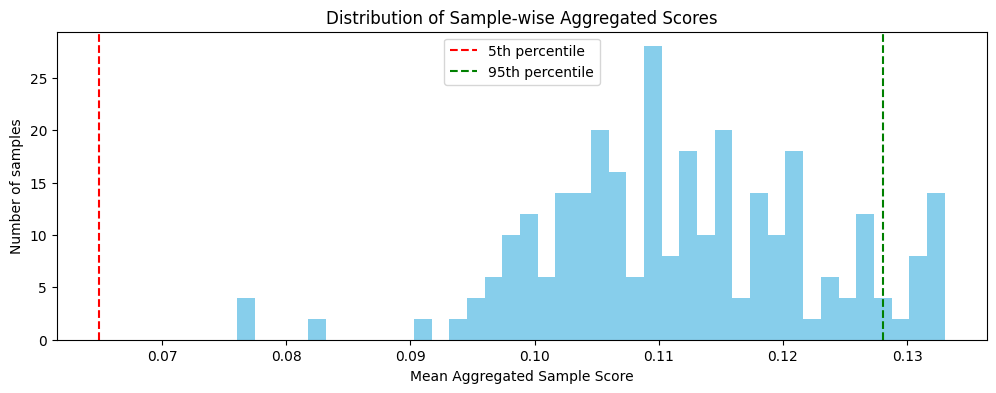

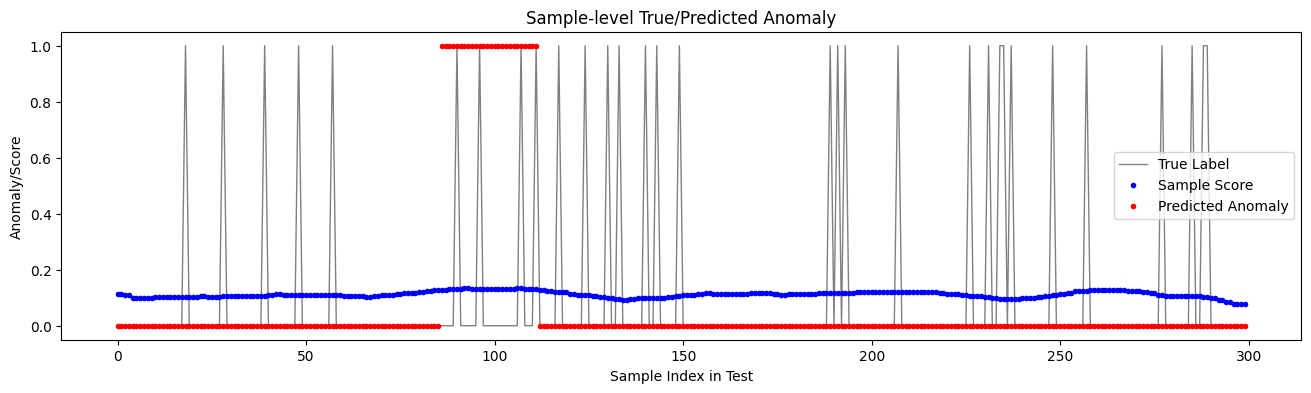

In [703]:
num_test_samples = len(test_df)
sample_score_sums = np.zeros(num_test_samples)
sample_score_counts = np.zeros(num_test_samples)
for i, idx_win in enumerate(test_indices):
    for j in idx_win:
        if j < num_test_samples:
            sample_score_sums[j] += test_scores[i]
            sample_score_counts[j] += 1
sample_scores = np.where(sample_score_counts > 0, sample_score_sums / sample_score_counts, 0)

sample_pred = ((sample_scores > upper_th) | (sample_scores < lower_th)).astype(int)

sample_true = (test_labels == 1).astype(int)
print("Sample-level Classification Report:")
print(classification_report(sample_true, sample_pred, zero_division=0))

print("Sample-level Confusion Matrix:")
print(confusion_matrix(sample_true, sample_pred))

print("Sample-level ROC AUC Score:", roc_auc_score(sample_true, sample_scores))

plt.figure(figsize=(12, 4))
plt.hist(sample_scores, bins=40, color='skyblue')
plt.axvline(lower_th, color='red', linestyle='--', label='5th percentile')
plt.axvline(upper_th, color='green', linestyle='--', label='95th percentile')
plt.xlabel('Mean Aggregated Sample Score')
plt.ylabel('Number of samples')
plt.legend()
plt.title('Distribution of Sample-wise Aggregated Scores')
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(range(num_test_samples), sample_true, 'gray', lw=1, label='True Label')
plt.plot(range(num_test_samples), sample_scores, 'b.', label='Sample Score')
plt.plot(range(num_test_samples), sample_pred, 'r.', label='Predicted Anomaly')
plt.legend()
plt.title('Sample-level True/Predicted Anomaly')
plt.xlabel('Sample Index in Test')
plt.ylabel('Anomaly/Score')
plt.show()


#  Sample-level aggregation using Max

Sample-level Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.36      0.52       269
           1       0.11      0.68      0.19        31

    accuracy                           0.40       300
   macro avg       0.51      0.52      0.35       300
weighted avg       0.82      0.40      0.49       300

Sample-level Confusion Matrix:
[[ 98 171]
 [ 10  21]]
Sample-level ROC AUC Score: 0.47841467801894705


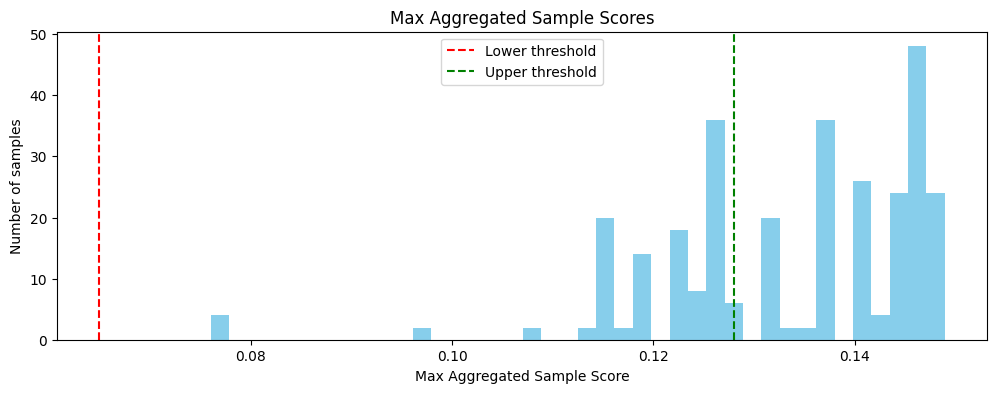

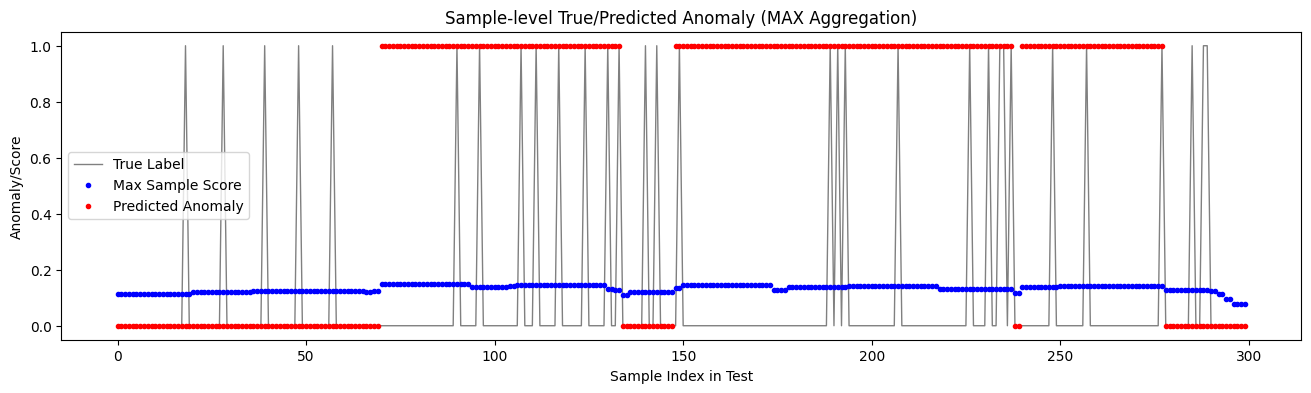

In [704]:
num_test_samples = len(test_df)
sample_score_max = np.full(num_test_samples, -np.inf)  # Start with very low values

for i, idx_win in enumerate(test_indices):
    for j in idx_win:
        if j < num_test_samples:
            sample_score_max[j] = max(sample_score_max[j], test_scores[i])


sample_scores = np.where(sample_score_max > -np.inf, sample_score_max, 0)
sample_pred = ((sample_scores > upper_th) | (sample_scores < lower_th)).astype(int)
sample_true = (test_labels == 1).astype(int)
print("Sample-level Classification Report:")
print(classification_report(sample_true, sample_pred, zero_division=0))
print("Sample-level Confusion Matrix:")
print(confusion_matrix(sample_true, sample_pred))
print("Sample-level ROC AUC Score:", roc_auc_score(sample_true, sample_scores))

plt.figure(figsize=(12, 4))
plt.hist(sample_scores, bins=40, color='skyblue')
plt.axvline(lower_th, color='red', linestyle='--', label='Lower threshold')
plt.axvline(upper_th, color='green', linestyle='--', label='Upper threshold')
plt.xlabel('Max Aggregated Sample Score')
plt.ylabel('Number of samples')
plt.legend()
plt.title('Max Aggregated Sample Scores')
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(range(num_test_samples), sample_true, 'gray', lw=1, label='True Label')
plt.plot(range(num_test_samples), sample_scores, 'b.', label='Max Sample Score')
plt.plot(range(num_test_samples), sample_pred, 'r.', label='Predicted Anomaly')
plt.legend()
plt.title('Sample-level True/Predicted Anomaly (MAX Aggregation)')
plt.xlabel('Sample Index in Test')
plt.ylabel('Anomaly/Score')
plt.show()


# Sample-level aggregation using Median

Sample-level Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       269
           1       0.14      0.19      0.16        31

    accuracy                           0.79       300
   macro avg       0.52      0.53      0.52       300
weighted avg       0.82      0.79      0.81       300

Sample-level Confusion Matrix:
[[231  38]
 [ 25   6]]
Sample-level ROC AUC Score: 0.44351840748291166


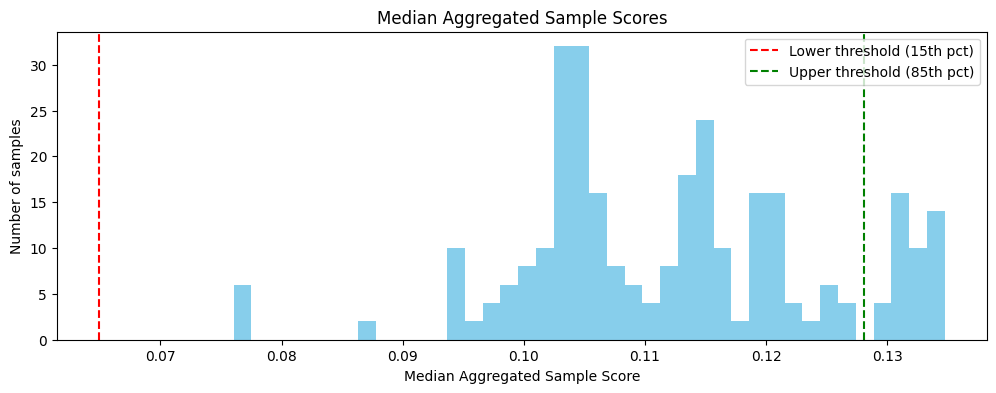

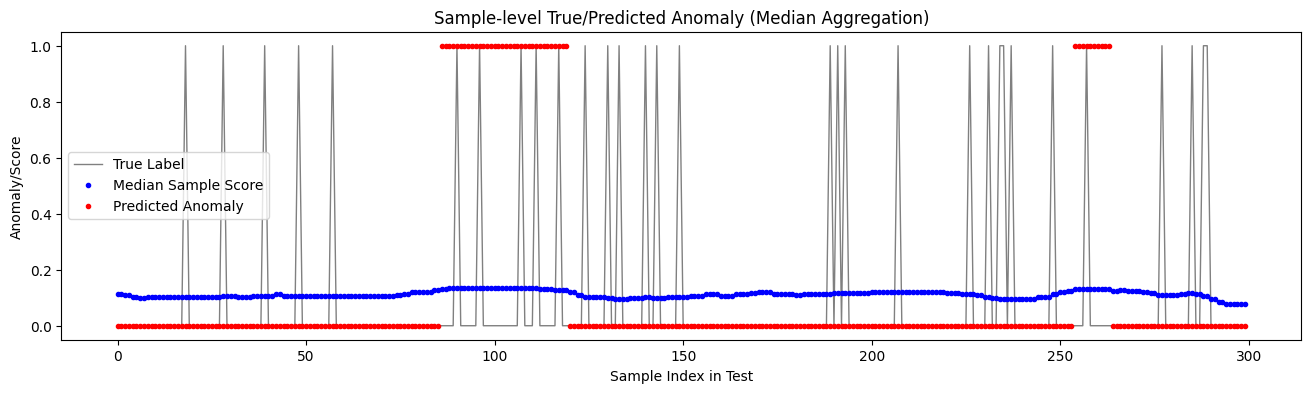

In [705]:
num_test_samples = len(test_df)
sample_scores = np.zeros(num_test_samples)
for j in range(num_test_samples):

    scores_for_j = [test_scores[i] for i, idx_win in enumerate(test_indices) if j in idx_win]
    if len(scores_for_j) > 0:
        sample_scores[j] = np.median(scores_for_j)
    else:
        sample_scores[j] = 0.0

sample_pred = ((sample_scores > upper_th) | (sample_scores < lower_th)).astype(int)
sample_true = (test_labels == 1).astype(int)

print("Sample-level Classification Report:")
print(classification_report(sample_true, sample_pred, zero_division=0))

print("Sample-level Confusion Matrix:")
print(confusion_matrix(sample_true, sample_pred))

print("Sample-level ROC AUC Score:", roc_auc_score(sample_true, sample_scores))

plt.figure(figsize=(12, 4))
plt.hist(sample_scores, bins=40, color='skyblue')
plt.axvline(lower_th, color='red', linestyle='--', label='Lower threshold (15th pct)')
plt.axvline(upper_th, color='green', linestyle='--', label='Upper threshold (85th pct)')
plt.xlabel('Median Aggregated Sample Score')
plt.ylabel('Number of samples')
plt.legend()
plt.title('Median Aggregated Sample Scores')
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(range(num_test_samples), sample_true, 'gray', lw=1, label='True Label')
plt.plot(range(num_test_samples), sample_scores, 'b.', label='Median Sample Score')
plt.plot(range(num_test_samples), sample_pred, 'r.', label='Predicted Anomaly')
plt.legend()
plt.title('Sample-level True/Predicted Anomaly (Median Aggregation)')
plt.xlabel('Sample Index in Test')
plt.ylabel('Anomaly/Score')
plt.show()